In [1]:
import pandas as pd
import numpy as np
import datetime as dt

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("data.csv")

test = list(df['power'].loc[71424:])

In [30]:
df

,Unnamed: 0,date,time,power,workday
0,0,2022-01-01,0.00,0.000000e+00,0
1,1,2022-01-01,0.25,0.000000e+00,0
2,2,2022-01-01,0.50,0.000000e+00,0
3,3,2022-01-01,0.75,0.000000e+00,0
4,4,2022-01-01,1.00,0.000000e+00,0
...,...,...,...,...,...
77947,77947,2024-03-22,22.75,-1.367699e-07,1
77948,77948,2024-03-22,23.00,-1.367699e-07,1
77949,77949,2024-03-22,23.25,-1.367699e-07,1
77950,77950,2024-03-22,23.50,-1.367699e-07,1


In [3]:
forecast = list(df['power'])[71424 - 96*7: -96*7]


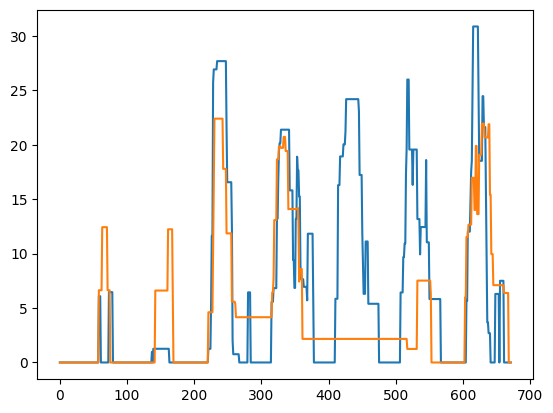

In [25]:
plt.plot(test[-96*7:])
plt.plot(forecast[-96*7:])

In [13]:
from sklearn.metrics import root_mean_squared_error

rmse = root_mean_squared_error(test, forecast)
rmse

8.072863783465985

In [14]:
alpha = 2


weights = np.array([alpha if num == 1 else 1 for num in np.sign(np.array(test) - np.array(forecast))])
wmse = np.sqrt(np.mean(weights**2 * (np.array(test) - np.array(forecast))**2))

print(f"RMSE={rmse}\tWRMSE={wmse}")

RMSE=8.072863783465985	WRMSE=12.82574819287365


In [33]:
forecast[:10]

[-1.367699198340233e-07,
 -1.367699198340233e-07,
 -1.367699198340233e-07,
 -1.367699198340233e-07,
 -1.367699198340233e-07,
 -1.367699198340233e-07,
 -1.367699198340233e-07,
 -1.367699198340233e-07,
 -1.367699198340233e-07,
 -1.367699198340233e-07]

In [34]:
test[:10]

[-1.367699198340233e-07,
 -1.367699198340233e-07,
 -1.367699198340233e-07,
 -1.367699198340233e-07,
 -1.367699198340233e-07,
 -1.367699198340233e-07,
 -1.367699198340233e-07,
 -1.367699198340233e-07,
 -1.367699198340233e-07,
 -1.367699198340233e-07]

In [35]:
1 - sum(np.array(test) > np.array(forecast)) / len(test)

0.5813419117647058

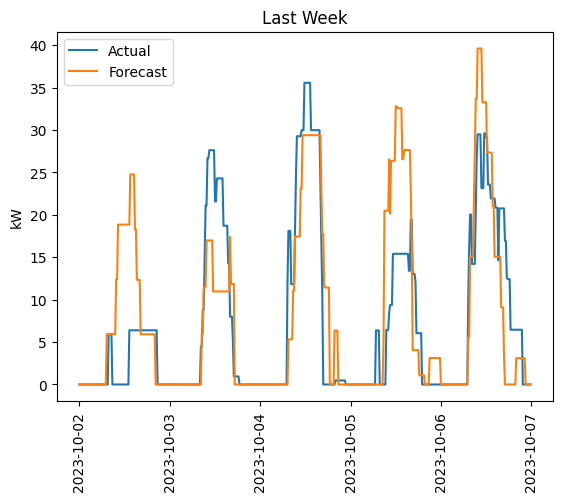

In [29]:
dates = list(df['date'])[-3356:]
dates = pd.date_range(start='2023-10-02', periods=96*5, freq='15min')
plt.plot(dates, test[:96*5], label="Actual")
plt.plot(dates, forecast[:96*5], label="Forecast")
plt.xticks(rotation=90)
plt.ylabel("kW")
plt.title("Last Week")
plt.legend();